In [12]:
%load_ext autoreload
%autoreload 2
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

sys.path.insert(0, '..')  # dataset.py lives one level up, shared across experiment types
import dataset
import rank_train
import runlog

from investalyze.analysis import encodings
from investalyze.ingest import storage

plt.rcParams['figure.dpi'] = 130

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
TICKERS = 2000  # list[str] of specific tickers, int for a random sample of that many, or None for all
UNIVERSE = 'mid_large_mega_non_fin_realest'  # name of a universe saved by the ticker selector app (data/universes/<name>.csv); overrides TICKERS when set
EXCLUDE_TICKERS = []  # tickers to always leave out, regardless of TICKERS or UNIVERSE
SEED = 0  # used when TICKERS is an int, and when VALID_METHOD is 'random'
WINDOW_LENGTH = 40
STRIDE = 10
HORIZON = 10  # trading days ahead to forecast the return over
LABEL = 'trend'  # 'point' / 'mean_exit' / 'vol_scaled' / 'trend' - what "future performance" means, see cell below
EXIT_HALFWIDTH = 2  # mean_exit and vol_scaled: exit price = mean of AC over HORIZON +/- this many days

VALID_FRAC = 0.3
VALID_METHOD = 'recent'  # 'recent' = time-based (no leakage) / 'random' = random per-window
TEST_N = 5  # always recent: the last N windows of each ticker

ENCODER = encodings.RebaseTo1  # swap by hand: RebaseTo100 / RebaseTo1 / encodings.zscore / encodings.minmax

RANK_OBJECTIVE = 'rank:ndcg'  # 'rank:pairwise' or 'rank:ndcg' (needs integer relevance grades, not used here)
N_ESTIMATORS = 500  # boosting rounds (upper bound; early stopping picks the best)
MAX_DEPTH = 40
LEARNING_RATE = 0.1
EARLY_STOPPING_ROUNDS = 100  # stop if valid ndcg hasn't improved in this many rounds
N_JOBS = -1

TOP_K_FRAC = 0.1  # precision@k: fraction of each day's tickers considered "top ranked"
RANK_TOLERANCE_FRAC = 0.025  # per-ticker success table: predicted rank within this fraction of the list length from the true rank
N_RELEVANCE_GRADES = 20  # eval-only: buckets future_return into per-date percentile grades for ndcg early stopping

### Parameter notes (the non-obvious ones)

`LABEL` and `RANK_OBJECTIVE` have their own cells below.

**`STRIDE`**: windows are anchored to shared reference dates (every STRIDE-th trading day across the whole
universe), not to per-ticker offsets. That's what makes every window's `end_date` land on the same calendar
grid, so each date has a cross-section of tickers to rank. Smaller stride = more windows, but neighbouring
windows overlap more (120-day windows 5 days apart share 115 days).

**`EXIT_HALFWIDTH`**: only used by the `mean_exit` and `vol_scaled` labels. The exit price is the mean of
adjusted close over `HORIZON ± EXIT_HALFWIDTH` days (2 → a 5-day average around the exit) instead of the
single day-HORIZON close, so one earnings gap landing exactly on the exit date can't decide a ticker's rank.
`0` reproduces `point` exactly; must stay below HORIZON.

**`VALID_FRAC` / `VALID_METHOD`**: `'recent'` carves each ticker's most recent windows into valid, so train
stays strictly earlier in time. `'random'` scatters valid windows through time: overlapping train windows
share most of a valid window's days, so valid scores read optimistic. Use `'recent'` for honest numbers,
`'random'` to check whether the model can learn at all.

**`TEST_N`**: the test set is always each ticker's last N windows (time-based, carved before valid; train
windows overlapping them are dropped). The per-ticker results table below averages a ticker's N predictions
and true labels into one rank slot.

**`ENCODER`**: how each window is normalized before the model sees it. `zscore` (mean 0/std 1 per window) and
`minmax` ([0, 1] per window) erase both price level and move size, keeping only the shape; `RebaseTo1` /
`RebaseTo100` keep relative move size (a window that doubled ends at 2 vs one that gained 10% at 1.1) and
erase only the absolute price level. The ranker can only use whatever survives the encoding.

**`N_ESTIMATORS` / `EARLY_STOPPING_ROUNDS`**: N_ESTIMATORS is just an upper bound on boosting rounds.
Training stops once valid NDCG hasn't improved for EARLY_STOPPING_ROUNDS consecutive rounds, and
`best_iteration` (the round predictions are taken from) marks the peak, so the effective model size is chosen
by the data, not by N_ESTIMATORS.

**`MAX_DEPTH`**: depth of each individual tree; each level doubles the possible leaves (2^depth), so values
past ~20 are effectively "unlimited" and a single tree can memorize whole training cross-sections. Typical
ranking setups use 4-10 and let boosting rounds do the work; at large depths early stopping is the only thing
still regularizing.

**`LEARNING_RATE`**: shrink factor applied to every tree's contribution. Lower values need more rounds but
average out more noise per step; 0.05-0.3 is the usual range.

**`TOP_K_FRAC`**: only used by the `precision_at_k` prints, never by training. Per end_date group: take the
top `round(n × TOP_K_FRAC)` tickers by predicted score and by true label, report the overlap fraction,
average over dates. Random guessing scores ≈ TOP_K_FRAC itself, so that's the no-skill baseline to read
against.

**`RANK_TOLERANCE_FRAC`**: only used by the per-ticker success table. A ticker is a success when its
predicted rank sits within `round(n_tickers × RANK_TOLERANCE_FRAC)` positions of its true rank (floor of 1
position). Random guessing lands within a fraction f of the true rank roughly 2f of the time (~5% at 0.025):
that's this table's no-skill baseline.

**`N_RELEVANCE_GRADES`**: NDCG needs small integer relevance grades, so each date's tickers are bucketed by
label percentile into this many grades (0 = worst, N-1 = best). Always applied to the valid set (the
early-stopping metric is NDCG); also applied to the training label when `RANK_OBJECTIVE = 'rank:ndcg'`. Keep
it ≤ 31: XGBoost's exponential gain (2^grade) errors out above that.

### `LABEL`: what each of the 4 options measures

All four are computed from the split/dividend-adjusted close (`AC`) over the HORIZON trading days after
the window ends; the model's input window (raw OHLCV) is identical in every case. Only the definition of
"did well" that the ranking is trained against changes. Windows that can't be labelled (e.g. `mean_exit`
needs EXIT_HALFWIDTH extra days after the horizon) are dropped, so window counts differ slightly per option.

#### `'point'`
Return between the window's last close and the close exactly HORIZON days later:
`AC[end+HORIZON] / AC[end] - 1`. The classic forward return, but the whole label hangs on a single
closing price: one earnings gap or bad day landing exactly on that date decides the ticker's rank
(exit-date luck), and high-volatility tickers fill both extremes of the ranking just because they move more.

#### `'mean_exit'`
Same return, but the exit price is the mean of `AC` over `HORIZON ± EXIT_HALFWIDTH` days. Averaging a few
days around the exit removes most single-day exit luck while measuring the same thing. With
`EXIT_HALFWIDTH = 0` it is exactly `'point'`.

#### `'vol_scaled'`
The `'mean_exit'` return divided by the ticker's trailing volatility (std of daily log returns of `AC`
inside the input window). Asks "how big was the move relative to how much this ticker normally moves": a
quiet stock grinding up 4% can outrank a biotech that jumped 8% on noise. This is the main defense against
high-vol names monopolizing the top and bottom grades. Values are in vol units, not returns.

#### `'trend'`
Slope of a straight line fitted through `log(AC)` over the HORIZON path, multiplied by the fit's R².
Rewards smooth, consistent drift: a flat path ending in one big gap gets a low R² and scores near zero even
if its endpoint return is large. Labels a genuinely different thing than the other three, trend quality over
the whole path rather than the endpoint. Values are log-return-per-day times fit quality; only the per-date
rank order matters for training anyway.

### `RANK_OBJECTIVE`: what each of the 2 options actually does

This param takes either `'rank:pairwise'` or `'rank:ndcg'`. Two genuinely different algorithms,
explained on equal footing below - what each one does, and when you'd want one over the other.

#### Background: what NDCG is and where it comes from

NDCG = **N**ormalized **D**iscounted **C**umulative **G**ain. It comes from a 2002 information-
retrieval paper for scoring search engines - "did Google put the best web page first" - reused
here because "rank the best stock first" is mathematically the identical problem: you have a list
you produced (predicted order) and a true ground truth (actual order), and you want one number
saying how good your list was. Both options below are built around this formula (one uses it only
to check progress, the other optimizes it directly), so it's worth understanding fully regardless
of which you pick.

**1. Relevance / "grade"** - a small whole number saying how good an item truly is. This concept
comes from the original search-engine use case (human judges rating "how relevant is this page to
the query" on a small scale, e.g. 0-4). In our code, this *is* `relevance_grades()`'s output: grade
0 = worst-return quintile that day, grade 4 = best. "Relevance" and "grade" are the same number,
just two names for it - one from where the formula originated, one from our code.

**2. Gain** - the reward for a grade, defined as `gain = 2^grade - 1`:

| grade | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| gain | 0 | 1 | 3 | 7 | 15 |

Doubling per grade, not adding - correctly flagging a top (grade 4) ticker is worth far more than a
mediocre (grade 1) one, not just "a bit more." This exponential shape is a deliberate design choice
in the original formula, to make the reward heavily favor identifying genuinely excellent items
over merely decent ones.

**3. Discount** - reward shrinks the further down your *predicted* list an item lands:
`discount = 1 / log2(position + 1)`. Position 1 vs 2 barely shrinks (1.0 vs 0.63); by position 10
it's much smaller. This encodes "it matters a lot whether the best ticker is picked #1 or #2, much
less whether some average ticker is #47 or #48" - position near the top is far more consequential
than position further down.

**4. DCG (Discounted Cumulative Gain)** - add up `gain × discount` for every ticker, in the order
**the model predicted**. One number for "how good was this predicted ranking," combining both how
good each pick actually was and where it landed.

**5. IDCG (Ideal DCG)** - the same sum, but using the **true** best-to-worst order instead of the
model's guess - i.e. the maximum possible score achievable for that day's tickers. This is the
"perfect score" reference point.

**6. NDCG = DCG / IDCG** - your score divided by the best possible score, giving 0-1 (1 = predicted
order exactly matches the true order). Dividing by IDCG is what makes NDCG comparable across
different days even when they have different numbers of tickers or different best-return sizes -
without this normalization, a day with one huge winner would trivially produce bigger raw DCG
numbers than a calm day, regardless of how good the ranking was.

**Worked example** - true order (best to worst): A(grade 3), B(grade 2), C(grade 1), D(grade 0).
Say the model predicted: B, A, D, C (swapped the top two, and the bottom two).

| | gain | true DCG (pos, discount) | predicted DCG (pos, discount) |
|---|---|---|---|
| A | 7 | pos 1 → 7×1.0=7.0 | pos 2 → 7×0.63=4.42 |
| B | 3 | pos 2 → 3×0.63=1.89 | pos 1 → 3×1.0=3.0 |
| C | 1 | pos 3 → 1×0.5=0.5 | pos 4 → 1×0.43=0.43 |
| D | 0 | pos 4 → 0×0.43=0 | pos 3 → 0×0.5=0 |

IDCG = 7 + 1.89 + 0.5 + 0 = 9.39. DCG (predicted) = 4.42 + 3.0 + 0.43 + 0 = 7.85.
**NDCG = 7.85 / 9.39 ≈ 0.84.**

The swap at the bottom (C/D) cost nothing - D has grade 0 so its position is irrelevant - while the
swap at the top (A/B) is what actually dragged the score down from 1.0. That's NDCG's whole point:
mistakes among your best picks matter far more than mistakes among your worst ones.

**Why grades/buckets exist at all, for either option:** the real target, `future_return`, is a
continuous number like `0.073`, not a small whole number - feeding that into NDCG's formula (or
into `rank:ndcg` as a training objective) throws an outright error (verified: "label must be either
0 or positive integer"). Feeding it fine-grained dense ranks (1st, 2nd, 3rd... out of hundreds)
instead would make `2^rank` a numerically meaningless giant number - the formula assumes a handful
of coarse categories, not hundreds of fine ones. So wherever NDCG is used (as eval metric or as
training objective), `relevance_grades()` buckets each day's tickers by return percentile into
`N_RELEVANCE_GRADES` groups (default 5 = quintiles) first.

#### Option A: `'rank:pairwise'`

**Mechanics:** for every *pair* of tickers on the same day, it asks one yes/no question - "did I
score the actually-better one higher?" (this specific algorithm is called RankNet). It works
directly on continuous `future_return` for training - no bucketing needed, because it only needs to
know which of two numbers is bigger, not by how much.

**Verified fact:** this loss does *not* use the size of the gap between two tickers' returns.
Tested it directly: trained two rankers on identical orderings but wildly different gaps (tiny
fractional differences vs. the same order cubed into huge, unequal gaps) - byte-for-byte identical
predictions both times. It also treats every pair about equally regardless of where it sits in the
ranking - no extra weight on top-of-list pairs.

**Pros:**
- Trains on the full continuous target directly - no bucketing/information-discarding step needed.
- Never creates ties: continuous values are practically always distinct, so every pair has a clear
  direction to learn from (bucketing into grades, by contrast, makes many tickers share a grade
  with no defined order between them, wasting those pairs).
- Simpler, well-established, classic method.

**Cons:**
- Completely ignores how *much* better one ticker did than another - a narrow win and a landslide
  win are treated identically.
- No special emphasis on the top of the ranking - a mistake between the 2 best tickers costs the
  same as a mistake between two mediocre ones.

**When to use it:** when you care about the ranking's overall/whole-list agreement rather than
specifically the extreme top, or when you'd rather not lose information by bucketing your target
into a handful of grades before training.

#### Option B: `'rank:ndcg'`

**Mechanics:** directly optimizes the NDCG formula above *during training* (this algorithm is
called LambdaMART) - so unlike pairwise, it explicitly pushes harder to fix mistakes near the top
(high-grade) of the ranking than near the bottom (low-grade), matching NDCG's own gain/discount
shape.

To do that, it needs the same graded relevance NDCG's formula always needs - confirmed by actually
training with it: passing continuous `future_return` as the label throws the identical
integer-only error the eval metric does. So using this option means bucketing your *training*
labels into grades too, not just the monitoring number.

**Pros:**
- Explicitly optimizes for "get the top picks right," which is usually what a real strategy
  (invest in your top-K names) actually needs.
- Position-sensitivity is baked into training itself, not just how you evaluate afterward.
- Bucketing training labels arguably reflects reality better in a noisy market: the exact
  difference between the ticker that finished #47 and #48 that day is mostly noise anyway, so
  not asking the model to fit that level of precision could be a feature, not just a cost.

**Cons:**
- Requires bucketing the real, continuous return into a handful of grades before training - fine
  distinctions within a grade are discarded, and tickers sharing a grade become ties (same problem
  pairwise avoids, but now affecting the actual training signal, not just monitoring).
- More setup: needs `N_RELEVANCE_GRADES`-style bucketing wired into the training data too, not just
  the eval set.

**When to use it:** when your real downstream use case is specifically "pick the top-K stocks"
(matches how `precision_at_k` evaluates things) and you're fine with - or actively prefer - coarser
training labels that don't chase noise-level distinctions between adjacent ranks.

**Practical note:** the training cell handles this automatically: with `'rank:ndcg'` it buckets
`y_train` into `N_RELEVANCE_GRADES` grades before `.fit()`, with `'rank:pairwise'` it passes the
continuous target through untouched. The eval set is bucketed either way, because the
early-stopping metric is always NDCG. XGBoost's default exponential gain caps grades at 31, so
keep `N_RELEVANCE_GRADES <= 31`.

In [16]:
DATA_ROOT = Path('../../data')

con = storage.connect(DATA_ROOT, read_only=True)
if UNIVERSE is not None:
    tickers = [t for t in dataset.load_universe(UNIVERSE, DATA_ROOT) if t not in EXCLUDE_TICKERS]
elif isinstance(TICKERS, int):
    tickers = dataset.sample_tickers(con, TICKERS, seed=SEED, exclude=EXCLUDE_TICKERS)
else:
    tickers = TICKERS
series = dataset.get_ohlcv_series(con, tickers, exclude=EXCLUDE_TICKERS)
con.close()
print('tickers used', tickers if tickers is not None else 'ALL')

channels, meta = dataset.build_windows_with_future_return(
    series, window_length=WINDOW_LENGTH, stride=STRIDE, horizon=HORIZON, label=LABEL, exit_halfwidth=EXIT_HALFWIDTH
)
print('windows', meta.shape[0], 'across', meta['Ticker'].nunique(), 'tickers')

tickers used ['A', 'AA', 'AAL', 'AAOI', 'AAON', 'AAP', 'AAPL', 'ABBV', 'ABCL', 'ABG', 'ABM', 'ABNB', 'ABT', 'ACA', 'ACAD', 'ACHC', 'ACHR', 'ACI', 'ACIW', 'ACLS', 'ACLX', 'ACM', 'ACMR', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADMA', 'ADP', 'ADPT', 'ADSK', 'ADT', 'AEE', 'AEHR', 'AEIS', 'AEM', 'AEO', 'AEP', 'AG', 'AGCO', 'AGI', 'AGIO', 'AGX', 'AGYS', 'AIN', 'AIR', 'AIT', 'AKAM', 'AKTS', 'AKTX', 'ALB', 'ALG', 'ALGM', 'ALGN', 'ALGT', 'ALHC', 'ALK', 'ALKS', 'ALLE', 'ALMU', 'ALNY', 'ALRM', 'ALSN', 'ALV', 'AMAT', 'AMBA', 'AMD', 'AME', 'AMGN', 'AMKR', 'AMR', 'AMRN', 'AMRX', 'AMRZ', 'AMZN', 'AN', 'ANDE', 'ANET', 'ANF', 'AOS', 'APA', 'APC', 'APD', 'APGE', 'APH', 'APLD', 'APLS', 'APP', 'APPF', 'APTV', 'AR', 'ARCB', 'ARLP', 'ARM', 'ARMK', 'AROC', 'ARW', 'ARWR', 'ASO', 'ASTS', 'ATEN', 'ATEX', 'ATI', 'ATKR', 'ATMU', 'ATO', 'ATR', 'ATRO', 'AUPH', 'AUR', 'AVA', 'AVAV', 'AVGO', 'AVNT', 'AVPT', 'AVT', 'AVTR', 'AVY', 'AWI', 'AWK', 'AWR', 'AXGN', 'AXON', 'AXSM', 'AXTA', 'AXTI', 'AYI', 'AZO', 'AZZ', 'BA', 'BAH', 'BAL

In [17]:
train_mask, valid_mask, test_mask = dataset.split_windows(meta, valid_frac=VALID_FRAC, valid_method=VALID_METHOD, test_n=TEST_N, seed=SEED)

print('train windows', int(train_mask.sum()), 'valid windows', int(valid_mask.sum()), 'test windows', int(test_mask.sum()))
group_sizes = meta.groupby('end_date').size()
print('cross-sectional group size: median', int(group_sizes.median()), 'max', int(group_sizes.max()))
# ranking only cares about within-group relative order, so the raw future_return works directly - no
# demeaning needed (a per-group additive shift doesn't change the order)
meta['future_return'].describe()
X_flat = dataset.encode_windows_flat(channels, ENCODER)  # float32, one row per window - the layout xgboost consumes
y = meta['future_return'].to_numpy()
end_dates = meta['end_date'].to_numpy()


def take_sorted_by_group(
    x: np.ndarray, y: np.ndarray, dates: np.ndarray, mask: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    idx = np.flatnonzero(mask)
    idx = idx[np.argsort(dates[idx], kind='stable')]  # xgboost's qid requires rows grouped contiguously
    dates_sorted = dates[idx]
    _, qid = np.unique(dates_sorted, return_inverse=True)
    return x[idx], y[idx], dates_sorted, qid.astype(np.uint32)


X_train, y_train, dates_train, qid_train = take_sorted_by_group(X_flat, y, end_dates, train_mask)
X_valid, y_valid, dates_valid, qid_valid = take_sorted_by_group(X_flat, y, end_dates, valid_mask)
X_test, y_test, dates_test, qid_test = take_sorted_by_group(X_flat, y, end_dates, test_mask)


del X_flat  # the three split arrays above hold the same rows; re-running this cell recreates it


train windows 539153 valid windows 226521 test windows 6215
cross-sectional group size: median 393 max 1243


In [18]:
# eval metric is always ndcg, which needs graded relevance, not the raw continuous return - bucket
# valid's future_return into per-date percentile grades regardless of which objective is used below.
valid_grades = rank_train.relevance_grades(y_valid, qid_valid, n_grades=N_RELEVANCE_GRADES)

# rank:ndcg needs the same graded relevance for the TRAINING label too (errors on continuous input);
# rank:pairwise trains fine on the raw continuous future_return - see the markdown cell above for why.
if RANK_OBJECTIVE == 'rank:ndcg':
    train_target = rank_train.relevance_grades(y_train, qid_train, n_grades=N_RELEVANCE_GRADES)
else:
    train_target = y_train

ranker = xgb.XGBRanker(
    objective=RANK_OBJECTIVE,
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    tree_method='hist',
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    eval_metric='ndcg',
    n_jobs=N_JOBS,
)
t0 = time.perf_counter()
ranker.fit(X_train, train_target, qid=qid_train, eval_set=[(X_valid, valid_grades)], eval_qid=[qid_valid], verbose=True)
train_seconds = time.perf_counter() - t0
print(f'best iteration {ranker.best_iteration} / {N_ESTIMATORS}, trained in {train_seconds:.0f}s')

[0]	validation_0-ndcg:0.21963
[1]	validation_0-ndcg:0.22488
[2]	validation_0-ndcg:0.23639
[3]	validation_0-ndcg:0.24243
[4]	validation_0-ndcg:0.24653
[5]	validation_0-ndcg:0.24906
[6]	validation_0-ndcg:0.25229
[7]	validation_0-ndcg:0.25477
[8]	validation_0-ndcg:0.25385
[9]	validation_0-ndcg:0.25496
[10]	validation_0-ndcg:0.25581
[11]	validation_0-ndcg:0.25737
[12]	validation_0-ndcg:0.25676
[13]	validation_0-ndcg:0.25915
[14]	validation_0-ndcg:0.26115
[15]	validation_0-ndcg:0.26168
[16]	validation_0-ndcg:0.26191
[17]	validation_0-ndcg:0.26202
[18]	validation_0-ndcg:0.26153
[19]	validation_0-ndcg:0.26140
[20]	validation_0-ndcg:0.26124
[21]	validation_0-ndcg:0.26233
[22]	validation_0-ndcg:0.26371
[23]	validation_0-ndcg:0.26479
[24]	validation_0-ndcg:0.26490
[25]	validation_0-ndcg:0.26455
[26]	validation_0-ndcg:0.26495
[27]	validation_0-ndcg:0.26560
[28]	validation_0-ndcg:0.26575
[29]	validation_0-ndcg:0.26628
[30]	validation_0-ndcg:0.26592
[31]	validation_0-ndcg:0.26682
[32]	validation_0-

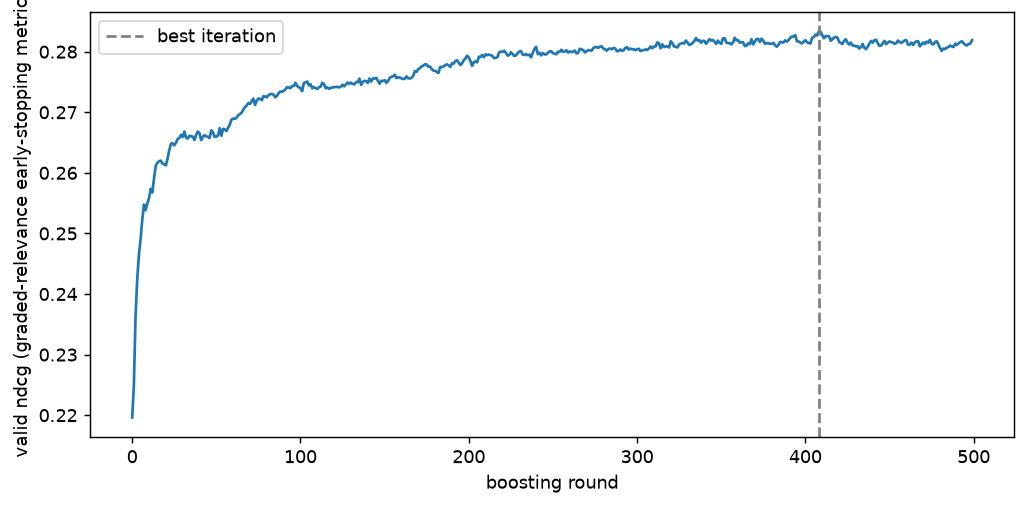

In [19]:
valid_ndcg = ranker.evals_result()['validation_0']['ndcg']
plt.figure(figsize=(8, 4))
plt.plot(valid_ndcg)
plt.axvline(ranker.best_iteration, color='gray', linestyle='--', label='best iteration')
plt.xlabel('boosting round')
plt.ylabel('valid ndcg (graded-relevance early-stopping metric)')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
valid_preds = ranker.predict(X_valid)
valid_corr = rank_train.spearman_by_group(valid_preds, y_valid, dates_valid)
valid_prec = rank_train.precision_at_k(valid_preds, y_valid, dates_valid, TOP_K_FRAC)
print(f'valid: per-date spearman={valid_corr:.4f}  precision@{TOP_K_FRAC:.0%}={valid_prec:.4f} (random baseline={TOP_K_FRAC:.4f})')

valid: per-date spearman=0.0018  precision@10%=0.1731 (random baseline=0.1000)


In [ ]:
test_preds = ranker.predict(X_test)
test_corr = rank_train.spearman_by_group(test_preds, y_test, dates_test)
test_prec = rank_train.precision_at_k(test_preds, y_test, dates_test, TOP_K_FRAC)
print(f'test: per-date spearman={test_corr:.4f}  precision@{TOP_K_FRAC:.0%}={test_prec:.4f} (random baseline={TOP_K_FRAC:.4f})')

SyntaxError: unterminated string literal (detected at line 2) (3343350456.py, line 2)

In [22]:
test_order = np.argsort(end_dates[test_mask], kind='stable')  # same ordering sort_by_group applied to X_test/y_test
test_ticker = meta.loc[test_mask, 'Ticker'].to_numpy()[test_order]
y_ticker = test_ticker  # same rows/order as test_ticker - included as an explicit alignment check

results = pd.DataFrame({'test_ticker': test_ticker, 'test_pred': test_preds, 'y_ticker': y_ticker, 'y_test': y_test})
results

,test_ticker,test_pred,y_ticker,y_test
0,CTA-PB,-3.651235,CTA-PB,0.000951
1,CTA-PB,-3.343468,CTA-PB,-0.000111
2,CTA-PB,-3.138479,CTA-PB,0.000413
3,CTA-PB,-3.626519,CTA-PB,-0.000215
4,CTA-PB,-3.899032,CTA-PB,0.000375
...,...,...,...,...
6210,ZKH,-2.332021,ZKH,-0.015780
6211,ZM,-1.822608,ZM,-0.004782
6212,ZS,-1.995871,ZS,0.000919
6213,ZTO,-4.380998,ZTO,-0.002057


In [23]:
# one row per ticker before ranking: with TEST_N > 1 each ticker has TEST_N test windows above, so average
# its predictions and true returns first - each ticker then holds exactly one rank slot and ranks run
# 1..n_tickers. With TEST_N = 1 the averages are the single window's values and nothing changes.
results = results.groupby('test_ticker', as_index=False)[['test_pred', 'y_test']].mean()

results['true_rank'] = results['y_test'].rank(ascending=False, method='min').astype(int)
results['pred_rank'] = results['test_pred'].rank(ascending=False, method='min').astype(int)

# per ticker: was it predicted within `tolerance` rank positions of its own true rank (not a fixed top-K
# cutoff) - the tolerance scales with the list length, so success rates compare across universe sizes
tolerance = max(1, round(len(results) * RANK_TOLERANCE_FRAC))
results['rank_diff'] = (results['pred_rank'] - results['true_rank']).abs()
results['success'] = results['rank_diff'] <= tolerance

print(f'{results["success"].sum()}/{len(results)} tickers predicted within {tolerance} rank positions of their true rank')
results.sort_values('true_rank')

75/1243 tickers predicted within 31 rank positions of their true rank


,test_ticker,test_pred,y_test,true_rank,pred_rank,rank_diff,success
48,AKTX,-0.758091,0.025037,1,11,10,True
757,MXL,-1.151982,0.022587,2,38,36,False
231,CLOV,-1.530612,0.019540,3,91,88,False
753,MU,-0.718867,0.017453,4,8,4,True
1004,SLS,-1.160677,0.017363,5,39,34,False
...,...,...,...,...,...,...,...
542,HYMC,-1.629422,-0.012881,1239,111,1128,False
538,HUBS,-2.273032,-0.013717,1240,305,935,False
283,CRWD,-1.001332,-0.025137,1241,22,1219,False
191,CAR,-1.130687,-0.025166,1242,33,1209,False


In [ ]:
# record this run: appends a comparison row to runs/runs.csv and saves the model + per-ticker results
# under runs/<run_id>/. Only run this cell when the run above is worth keeping.
run_params = {
    'universe': UNIVERSE or '',
    'tickers': 'all' if TICKERS is None else TICKERS if isinstance(TICKERS, int) else ','.join(TICKERS),
    'exclude': ','.join(EXCLUDE_TICKERS),
    'seed': SEED,
    'window_length': WINDOW_LENGTH,
    'stride': STRIDE,
    'horizon': HORIZON,
    'label': LABEL,
    'exit_halfwidth': EXIT_HALFWIDTH,
    'encoder': getattr(ENCODER, '__name__', repr(ENCODER)),
    'valid_frac': VALID_FRAC,
    'valid_method': VALID_METHOD,
    'test_n': TEST_N,
    'rank_objective': RANK_OBJECTIVE,
    'n_estimators': N_ESTIMATORS,
    'max_depth': MAX_DEPTH,
    'learning_rate': LEARNING_RATE,
    'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
    'n_relevance_grades': N_RELEVANCE_GRADES,
}
run_metrics = {
    'n_windows': len(meta),
    'n_tickers': meta['Ticker'].nunique(),
    'n_train': len(y_train),
    'n_valid': len(y_valid),
    'n_test': len(y_test),
    'train_seconds': round(train_seconds, 1),
    'n_rounds': ranker.get_booster().num_boosted_rounds(),
    'best_iteration': ranker.best_iteration,
    'best_valid_ndcg': round(ranker.best_score, 4),
    'spearman_valid': round(valid_corr, 4),
    'precision_at_k_valid': round(valid_prec, 4),
    'spearman_test': round(test_corr, 4),
    'precision_at_k_test': round(test_prec, 4),
    'top_k_frac': TOP_K_FRAC,
    'rank_tolerance_frac': RANK_TOLERANCE_FRAC,
    'tolerance': tolerance,
    'n_success': int(results['success'].sum()),
    'success_frac': round(float(results['success'].mean()), 4),
}
run_id = runlog.save_run(run_params, run_metrics, ranker, results)
print(f'recorded run {run_id}')